In [ ]:
import argparse
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn
from tqdm import trange

sys.path.insert(1, "/".join(os.path.abspath("").split("/")[0:-1]))

from importlib import reload

import models

reload(models)

<module 'models' from '/coc/flash12/cli726/_PoissonGradEstim/main/com_poisson/models.py'>

In [ ]:
dims = [8, 32]
n_samples_train = 1000
n_samples_test = 500
n_trials = 3

In [ ]:
def init_ground_truth_model(
    model: models.TwoLayerNetwork,
    trial: int,
    cfg: dict,
):

    with torch.inference_mode():

        # -------- 1. Structural weights --------
        for m in model.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                m.weight.mul_(cfg["weight_scale"])

                # baseline bias
                if m.bias is not None:
                    m.bias.normal_(
                        mean=cfg["bias_mean"],
                        std=cfg["bias_std"],
                    )

        # -------- 2. Latent prior --------
        model.prior_log_rate.normal_(
            mean=cfg["prior_log_rate_mean"],
            std=cfg["prior_log_rate_std"],
        )
        model.prior_log_nu.normal_(
            mean=cfg["prior_log_nu_mean"],
            std=cfg["prior_log_nu_std"],
        )

        # -------- 3. Dispersion (heterogeneity) --------
        model.encoder_log_nu.normal_(
            mean=cfg["encoder_log_nu_mean"],
            std=cfg["encoder_log_nu_std"],
        )
        model.decoder_log_nu.normal_(
            mean=cfg["decoder_log_nu_mean"],
            std=cfg["decoder_log_nu_std"],
        )

In [ ]:
cfg_list = [
    dict(
        weight_scale=0.5,  # linear, nonlinear 0.8
        bias_mean=-0.5,
        bias_std=0.3,
        prior_log_rate_mean=1.0,
        prior_log_rate_std=0.0,
        prior_log_nu_mean=0.0,
        prior_log_nu_std=0.5,
        encoder_log_nu_mean=0.0,
        encoder_log_nu_std=0.5,
        decoder_log_nu_mean=0.0,
        decoder_log_nu_std=0.5,
    ),
    dict(
        weight_scale=0.5,  # linear, nonlinear 0.8
        bias_mean=-0.5,
        bias_std=0.3,
        prior_log_rate_mean=1.0,
        prior_log_rate_std=0.0,
        prior_log_nu_mean=-1.0,
        prior_log_nu_std=0.0,
        encoder_log_nu_mean=-1.0,
        encoder_log_nu_std=0.0,
        decoder_log_nu_mean=-1.0,
        decoder_log_nu_std=0.0,
    ),
    dict(
        weight_scale=0.5,  # linear, nonlinear 0.8
        bias_mean=-0.5,
        bias_std=0.3,
        prior_log_rate_mean=1.0,
        prior_log_rate_std=0.0,
        prior_log_nu_mean=1.0,
        prior_log_nu_std=0.0,
        encoder_log_nu_mean=1.0,
        encoder_log_nu_std=0.0,
        decoder_log_nu_mean=1.0,
        decoder_log_nu_std=0.0,
    ),
]

In [ ]:
df = pd.DataFrame(
    index=np.arange(n_trials),
    columns=[
        "model",
        "x_train",
        "x_test",
        "z_train",
        "z_test",
    ],
)

for trial, cfg in zip(trange(n_trials), cfg_list):
    model = models.TwoLayerNetwork(
        dims=dims,
    )

    torch.manual_seed(trial)
    init_ground_truth_model(
        model=model,
        trial=trial,
        cfg=cfg,
    )

    z_train, x_train = model.sample(n_samples_train)
    z_test, x_test = model.sample(n_samples_test)

    df.at[trial, "model"] = model.state_dict()
    df.at[trial, "x_train"] = x_train
    df.at[trial, "x_test"] = x_test
    df.at[trial, "z_train"] = z_train
    df.at[trial, "z_test"] = z_test

df.to_pickle("data.pkl")

100%|██████████| 3/3 [00:00<00:00, 17.75it/s]


(array([3.800e+01, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        8.340e+02, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        2.714e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        2.704e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.317e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 3.220e+02, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 6.400e+01, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 6.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([0.        , 0.16      , 0.31999999, 0.47999999, 0.63999999,
        0.80000001, 0.95999998, 1.12      , 1.27999997, 1.44000006,
        1.60000002, 1.75999999, 1.91999996, 2.07999992, 2.24000001,
        2.4000001 , 2.55999994, 2.72000003, 2.88000011, 3.03999996,
        3.20000005, 3.3599999 , 3.51999998, 3.68000007, 3.83999991,
        4.        , 4.15999985, 4.32

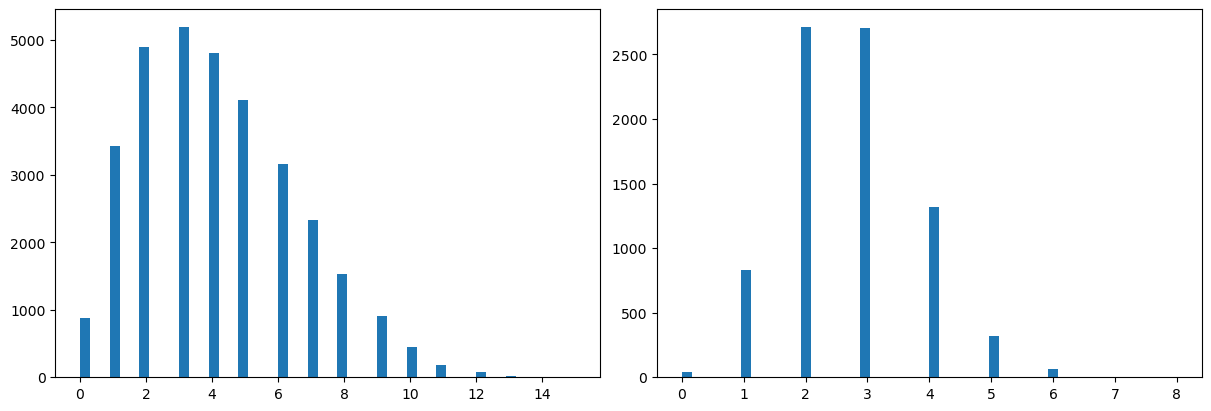

In [ ]:
trial = 2
x_train = df.at[trial, "x_train"]
z_train = df.at[trial, "z_train"]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
axs[0].hist(x_train.numpy().flatten(), bins=50)
axs[1].hist(z_train.numpy().flatten(), bins=50)

In [ ]:
model.state_dict()["prior_log_nu"].exp()

tensor([2.7183, 2.7183, 2.7183, 2.7183, 2.7183, 2.7183, 2.7183, 2.7183])